# 🌊 Buoy Correction - whacs Spectrum (Optional)

> **Inputs:**
> - Wave spectrum to be corrected in `.nc` format, located in the `inputs/` folder.
> - Satellite data in `.nc` format, also located in the `inputs/` folder.
> - *Optional:* Wave buoy data for validating the satellite-based correction.
>
> **⚠️NOTE:** Instructions for downloading the satellite data are available at:  
> https://github.com/javitausia/CalValWaves
>
> **Outputs:**
> - Satellite-corrected wave spectrum in `.nc` format, saved in the `inputs/` folder.  
>   This file can be used either for Super-Point construction (if needed) or directly as input for BinWaves.



---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk

- **BlueMath Toolkit Repository**:  [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

Before continuing, ensure you have **created and activated a Python environment**.

*** Other Required Packages ***
- `wavespectra` 
- `cartophy`
 
---

This Jupyter Notebook is an alternative step to correct whacs or other hindcast data with Satellite information. The corrected spectra can be use: 

1. Create the SuperPoint (Cagigal et al., 2023)
2. As a input to teh BinWaves Reconstrcution Notebook.

---
<details open>


The hindcast significant wave height data can be calibrated using both buoy and satellite significant height of waves as the "good" measure, but the way we prefer to do it is calibrating first with the satellite data and validating with the buoy after the calibration. A description of what is done can be seen in this paper:

João Albuquerque, Jose A. A. Antolínez, Ana Rueda, Fernando J.Méndez, Giovanni Cocoa (November 2018). Directional correction of modeled sea and swell wave heights using satellite altimeter data. https://doi.org/10.1016/j.ocemod.2018.09.001

</details>

---


> **For more information check the BlueMath Repo:** 
>
> https://github.com/GeoOcean/BlueMath/blob/main/toolkit/waves/CalVal_Carolinas.ipynb

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import os.path as op
from numpy import atan2
import wavespectra

In [2]:
seapoint_to_sample = 1911575
# buoy_coordinates= Lon: -74.839°, Lat: 36.612°
# WHACS Station Coordinates Lon: -74.8125°, Lat: 36.625°
station_lat=36.612
station_lon=-74.839+360
p_data = op.join(os.getcwd())
output_folder = op.join(p_data, 'outputs/44088_spec_WHACS.nc')

In [3]:
Hswell1 = xr.open_dataset("inputs/WHACS/north_carolina_phs1_WHACS.nc").phs1.sel(
    seapoint=seapoint_to_sample
)
Hs = xr.open_dataset("inputs/WHACS/north_carolina_hs_WHACS.nc").hs.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Dp = xr.open_dataset("inputs/WHACS/north_carolina_dp_WHACS.nc").dp.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
fp = xr.open_dataset("inputs/WHACS/north_carolina_fp_WHACS.nc").fp.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
DirM = xr.open_dataset("inputs/WHACS/north_carolina_dir_WHACS.nc").dir.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Hsea = xr.open_dataset("inputs/WHACS/north_carolina_phs0_WHACS.nc").phs0.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time    
)

Hswell2 = xr.open_dataset("inputs/WHACS/north_carolina_phs2_WHACS.nc").phs2.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Hswell3 = xr.open_dataset("inputs/WHACS/north_carolina_phs3_WHACS.nc").phs3.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Dirsea = xr.open_dataset("inputs/WHACS/north_carolina_pdp0_WHACS.nc").pdp0.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Dirswell1 = xr.open_dataset("inputs/WHACS/north_carolina_pdp1_WHACS.nc").pdp1.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Dirswell2 = xr.open_dataset("inputs/WHACS/north_carolina_pdp2_WHACS.nc").pdp2.sel(
    seapoint=seapoint_to_sample, time=Hswell1.time
)
Dirswell3 = xr.open_dataset("inputs/WHACS/north_carolina_pdp3_WHACS.nc").pdp3.sel(
    seapoint=seapoint_to_sample, time= Hswell1.time   
)


In [4]:
csiro = pd.DataFrame({
    'Hs':Hs.values,
    'Dm':Dp.values,
    'Tp':1/fp.values,
    'DirM':DirM.values,
    'Hsea': Hsea.values,
    'Hswell1': Hswell1.values,
    'Hswell2': Hswell2.values,
    'Hswell3': Hswell3.values,
    'Dirsea': Dirsea.values,
    'Dirswell1': Dirswell1.values,
    'Dirswell2': Dirswell2.values,
    'Dirswell3': Dirswell3.values,
}, index=pd.to_datetime(Hs.time.values))

# csiro.index = csiro.index.round('H')
lat = float(station_lat)
lon = float(station_lon)
csiro_lon, csiro_lat = lon, lat
csiro

,Hs,Dm,Tp,DirM,Hsea,Hswell1,Hswell2,Hswell3,Dirsea,Dirswell1,Dirswell2,Dirswell3
1979-01-01 00:00:00,0.574,87.0,16.393442,115.900002,0.454,0.268,0.158,0.140,144.600006,55.400002,86.400002,74.400002
1979-01-01 01:00:00,0.554,87.0,16.393442,113.099998,0.430,0.260,0.168,0.140,142.000000,55.299999,86.500000,74.400002
1979-01-01 02:00:00,0.556,87.0,16.393442,113.800003,0.434,0.256,0.176,0.140,142.500000,55.299999,86.900002,74.300003
1979-01-01 03:00:00,0.594,87.0,16.129032,119.800003,0.482,0.244,0.184,0.144,145.199997,53.200001,87.000000,74.599998
1979-01-01 04:00:00,0.636,87.0,16.129032,125.200005,0.530,0.238,0.198,0.138,149.100006,53.100002,87.099998,74.599998
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,0.688,106.0,10.204082,227.900009,0.508,0.332,0.264,0.142,286.500000,194.500000,105.200005,47.299999
2023-12-31 20:00:00,0.656,106.0,10.204082,215.900009,0.464,0.328,0.270,0.138,282.100006,194.699997,105.099998,47.299999
2023-12-31 21:00:00,0.634,106.0,10.204082,204.800003,0.452,0.298,0.276,0.136,281.700012,194.800003,105.000000,47.299999
2023-12-31 22:00:00,0.608,105.0,10.309278,191.500000,0.340,0.288,0.286,0.244,229.699997,104.900002,194.800003,317.200012


In [5]:
buoy = (
    pd.read_pickle(
        f"inputs/buoy_data/buoy_44088_bulk_parameters.pkl"
    )
    .rename(columns={"Hs_Buoy": "Hs_CAL"})
)
buoy['LATITUDE'] = station_lat
buoy['LONGITUDE'] = station_lon 
buoy = buoy.dropna(subset=['Hs_CAL'])
buoy

,Hs_CAL,Tm_Buoy,Tp_Buoy,Dir_Buoy,Spr_Buoy,LATITUDE,LONGITUDE
datetime,,,,,,,
2017-03-07 18:00:00,0.890,4.890,8.330,NaN,NaN,36.612,285.161
2017-03-07 19:00:00,0.905,4.685,9.090,NaN,NaN,36.612,285.161
2017-03-07 20:00:00,0.970,4.570,8.330,NaN,NaN,36.612,285.161
2017-03-07 21:00:00,1.035,4.420,9.090,NaN,NaN,36.612,285.161
2017-03-07 22:00:00,1.095,4.405,4.450,NaN,NaN,36.612,285.161
...,...,...,...,...,...,...,...
2024-12-31 19:00:00,1.005,5.035,7.410,146.0,NaN,36.612,285.161
2024-12-31 20:00:00,1.000,4.955,7.845,135.5,NaN,36.612,285.161
2024-12-31 21:00:00,1.025,4.800,7.410,143.0,NaN,36.612,285.161


### Comparison Wave Buoy vs Raw whacs spectrum

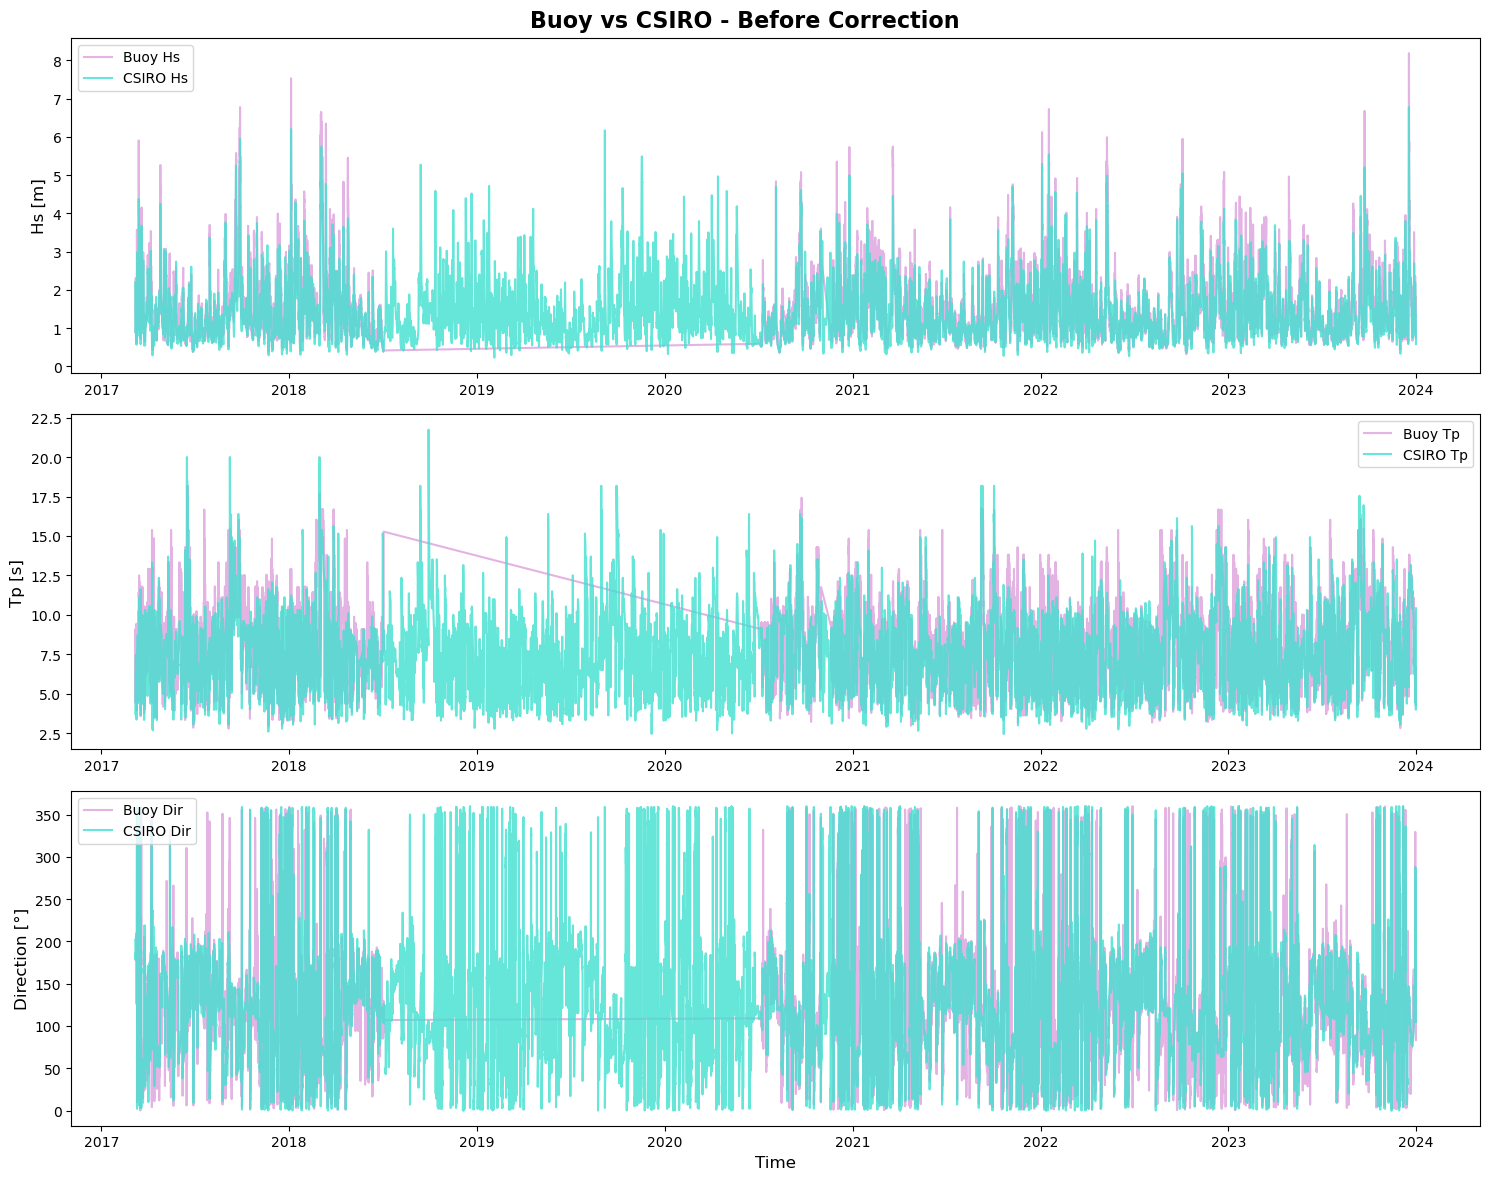

/tmp/ipykernel_2476590/31152866.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


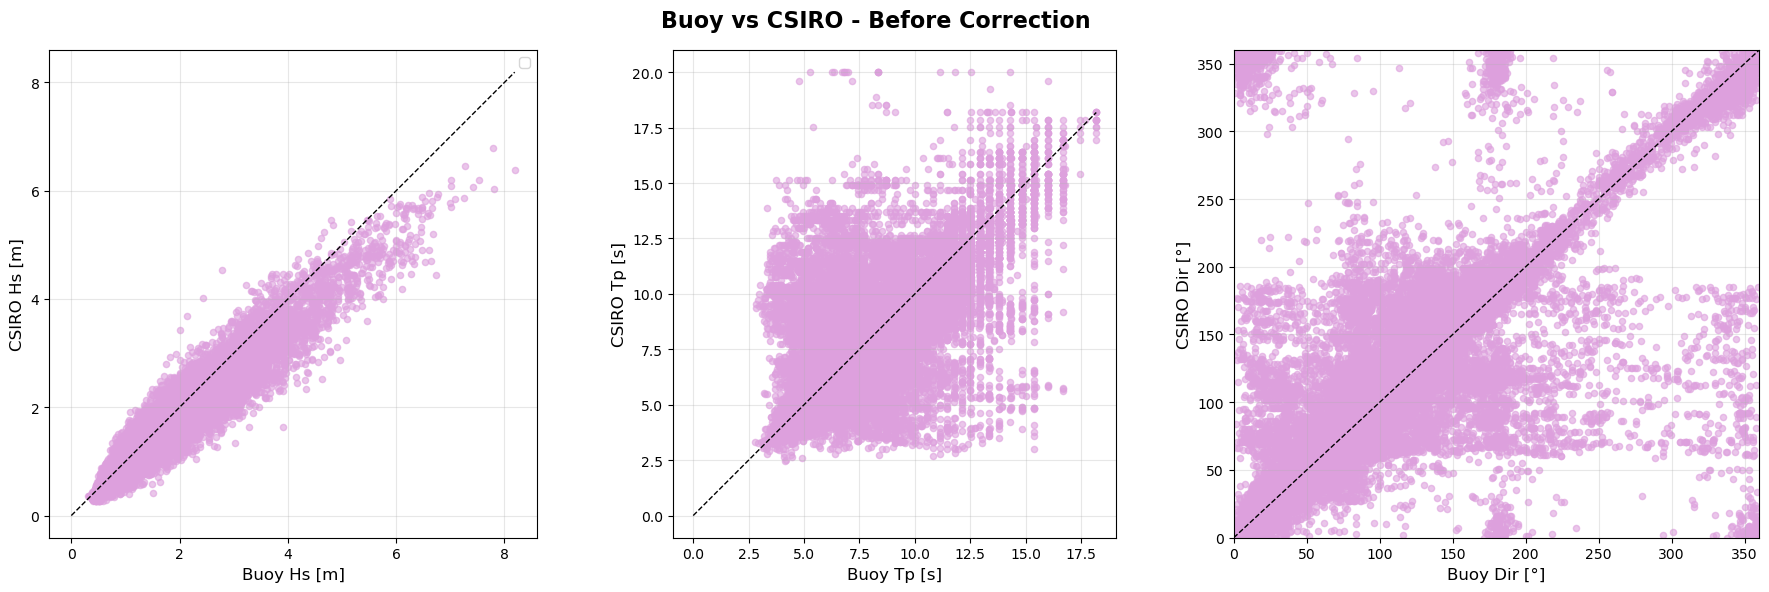

Data Statistics:
Common time period: 2017-03-07 18:00:00 to 2023-12-31 23:00:00
Number of common data points: 41282

Correlation coefficients:
Hs correlation: 0.959
Tp correlation: 0.659
Dir correlation: 0.624


In [6]:
# Plot comparison between buoy validation data and CSIRO data
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

# Create time series plot
fig1, axes = plt.subplots(3, 1, figsize=(15, 12))
fig1.suptitle('Buoy vs CSIRO - Before Correction', fontsize=16, fontweight='bold')

# Find common time range
common_start = max(buoy.index.min(), csiro.index.min())
common_end = min(buoy.index.max(), csiro.index.max())

# Filter data to common time range
buoy_common = buoy[(buoy.index >= common_start) & (buoy.index <= common_end)]
csiro_common = csiro[(csiro.index >= common_start) & (csiro.index <= common_end)]

# Hs time series
axes[0].plot(buoy_common.index, buoy_common['Hs_CAL'], color='plum', label='Buoy Hs', linewidth=1.5, alpha=0.8)
axes[0].plot(csiro_common.index, csiro_common['Hs'], color='turquoise', label='CSIRO Hs', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Hs [m]', fontsize=12)
axes[0].legend(fontsize=10)

# Tp time series
axes[1].plot(buoy_common.index, buoy_common['Tp_Buoy'], color='plum', label='Buoy Tp', linewidth=1.5, alpha=0.8)
axes[1].plot(csiro_common.index, csiro_common['Tp'], color='turquoise', label='CSIRO Tp', linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('Tp [s]', fontsize=12)
axes[1].legend(fontsize=10)

# Dir time series
axes[2].plot(buoy_common.index, buoy_common['Dir_Buoy'], color='plum', label='Buoy Dir', linewidth=1.5, alpha=0.8)
axes[2].plot(csiro_common.index, csiro_common['Dm'], color='turquoise', label='CSIRO Dir', linewidth=1.5, alpha=0.8)
axes[2].set_ylabel('Direction [°]', fontsize=12)
axes[2].set_xlabel('Time', fontsize=12)
axes[2].legend(fontsize=10)
plt.tight_layout()
plt.show()

# Create scatter plots
fig2, axes = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Buoy vs CSIRO - Before Correction', fontsize=16, fontweight='bold')

# Merge data on time index for scatter plots
merged_data = buoy_common.merge(csiro_common, left_index=True, right_index=True, how='inner')

# Hs scatter plot
axes[0].scatter(merged_data['Hs_CAL'], merged_data['Hs'], alpha=0.6, s=20, color='plum')
axes[0].plot([0, merged_data['Hs_CAL'].max()], [0, merged_data['Hs_CAL'].max()], 'k--', linewidth=1)
axes[0].set_xlabel('Buoy Hs [m]', fontsize=12)
axes[0].set_ylabel('CSIRO Hs [m]', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Tp scatter plot
axes[1].scatter(merged_data['Tp_Buoy'], merged_data['Tp'], alpha=0.6, s=20, color='plum')
axes[1].plot([0, merged_data['Tp_Buoy'].max()], [0, merged_data['Tp_Buoy'].max()], 'k--', linewidth=1)
axes[1].set_xlabel('Buoy Tp [s]', fontsize=12)
axes[1].set_ylabel('CSIRO Tp [s]', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

# Dir scatter plot
axes[2].scatter(merged_data['Dir_Buoy'], merged_data['Dm'], alpha=0.6, s=20, color='plum')
axes[2].plot([0, 360], [0, 360], 'k--', linewidth=1)
axes[2].set_xlabel('Buoy Dir [°]', fontsize=12)
axes[2].set_ylabel('CSIRO Dir [°]', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 360)
axes[2].set_ylim(0, 360)

plt.tight_layout()
plt.show()

# Print some statistics
print("Data Statistics:")
print(f"Common time period: {common_start} to {common_end}")
print(f"Number of common data points: {len(merged_data)}")
print("\nCorrelation coefficients:")
print(f"Hs correlation: {merged_data['Hs_CAL'].corr(merged_data['Hs']):.3f}")
print(f"Tp correlation: {merged_data['Tp_Buoy'].corr(merged_data['Tp']):.3f}")
print(f"Dir correlation: {merged_data['Dir_Buoy'].corr(merged_data['DirM']):.3f}")

In [7]:
from bluemath_tk.waves.calibration import CalVal
calval = CalVal()
calval

In [8]:
# Build a mask that includes ALL sea and swell columns
whacs_hindcast_data = csiro
cols = ['Hsea','Dirsea'] + [c for c in whacs_hindcast_data.columns if c.lower().startswith('hswell')]
cols += [c for c in whacs_hindcast_data.columns if c.lower().startswith('dirswell')]

mask = whacs_hindcast_data[cols].apply(np.isfinite).all(axis=1)
whacs_clean = whacs_hindcast_data.loc[mask].copy()

print("NaNs left in required columns:", (~np.isfinite(whacs_clean[cols])).sum().sum())


NaNs left in required columns: 0


/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:349: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if direcs[i] < 0:
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:351: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if direcs[i] > 0 and waves[i] > 0:
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:353: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consiste

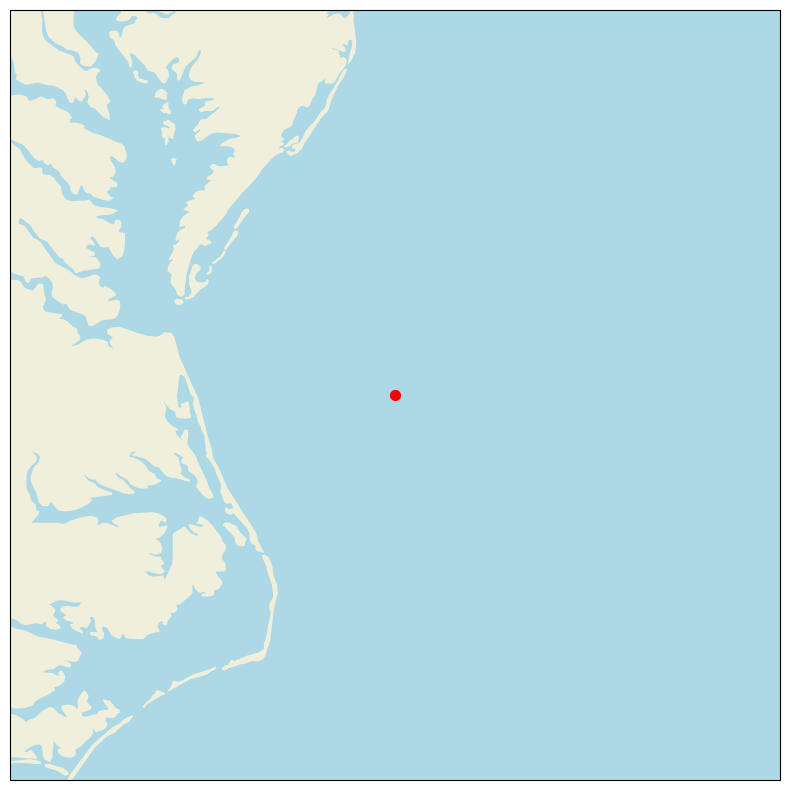

In [9]:
calval.fit(
    data=whacs_clean,
    data_longitude=csiro_lon,
    data_latitude=csiro_lat,
    data_to_calibrate=buoy,
    max_time_diff=1,
)

In [10]:
calval.calibration_params

{'sea_correction': {0: np.float64(1.120213101660759),
  1: np.float64(1.1256253040900603),
  2: np.float64(1.130736370900177),
  3: np.float64(1.1274940950136159),
  4: np.float64(1.1894636305295156),
  5: np.float64(1.1120565956041393),
  6: np.float64(1.1057473111105578),
  7: np.float64(0.9887168240377003),
  8: np.float64(0.892061628951832),
  9: np.float64(0.95686973451271),
  10: np.float64(1.1059775686217599),
  11: np.float64(1.129181984748245),
  12: np.float64(1.1807087791547775),
  13: np.float64(1.1518609676419422),
  14: np.float64(1.1742572582490154),
  15: np.float64(1.1463650544785606)},
 'swell_correction': {0: np.float64(1.1640477294127023),
  1: np.float64(1.1372651842555686),
  2: np.float64(1.1875704940196785),
  3: np.float64(1.0771728883698213),
  4: np.float64(1.1786573276945336),
  5: np.float64(1.081264934163273),
  6: np.float64(1.250561324821895),
  7: np.float64(1.1090885846507845),
  8: np.float64(1.0014713433064446),
  9: np.float64(0.8161698373913121),
 

/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/core/plotting/scatter.py:130: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x1, y1, z = x[idx], y[idx], z[idx]
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/waves/calibration.py:831: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
/vols/abedul/home/grupos/geocean/montanoj/Bluemath_tk_fork/BlueMath_tk/bluemath_tk/core/plotting/scatter.py:130: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value b

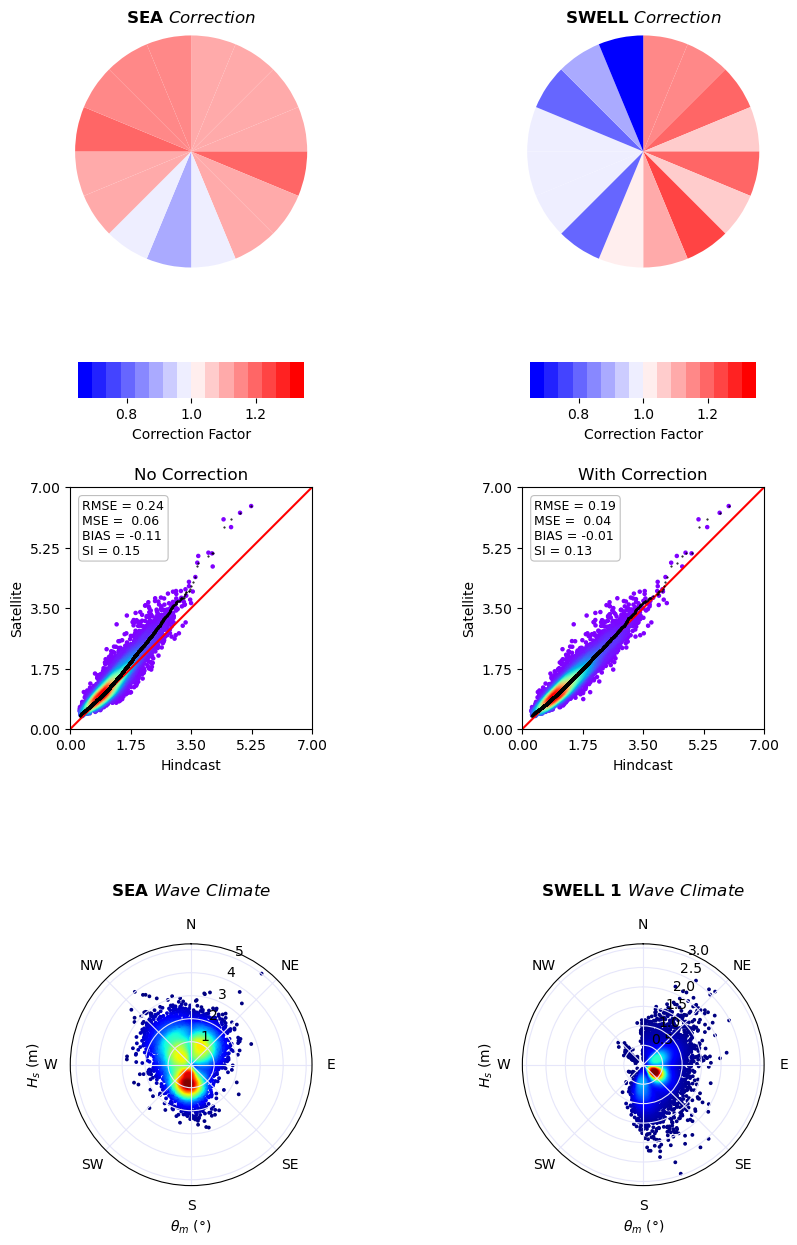

In [11]:
calval.plot_calibration_results();

In [13]:
corrected_csiro = calval.correct(data=csiro)
corrected_csiro

,Hs,Dm,Tp,DirM,Hsea,Hswell1,Hswell2,Hswell3,Dirsea,Dirswell1,Dirswell2,Dirswell3,Hs_CORR
1979-01-01 00:00:00,0.574,87.0,16.393442,115.900002,0.252013,0.101295,0.028966,0.022742,144.600006,55.400002,86.400002,74.400002,0.636409
1979-01-01 01:00:00,0.554,87.0,16.393442,113.099998,0.226073,0.095338,0.032748,0.022742,142.000000,55.299999,86.500000,74.400002,0.613923
1979-01-01 02:00:00,0.556,87.0,16.393442,113.800003,0.230299,0.092427,0.035942,0.022742,142.500000,55.299999,86.900002,74.300003,0.617583
1979-01-01 03:00:00,0.594,87.0,16.129032,119.800003,0.284057,0.083965,0.039283,0.024060,145.199997,53.200001,87.000000,74.599998,0.656784
1979-01-01 04:00:00,0.636,87.0,16.129032,125.200005,0.343450,0.079886,0.045488,0.022097,149.100006,53.100002,87.099998,74.599998,0.700658
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,0.688,106.0,10.204082,227.900009,0.359760,0.110549,0.096824,0.028438,286.500000,194.500000,105.200005,47.299999,0.771732
2023-12-31 20:00:00,0.656,106.0,10.204082,215.900009,0.300138,0.107901,0.101275,0.026858,282.100006,194.699997,105.099998,47.299999,0.732238
2023-12-31 21:00:00,0.634,106.0,10.204082,204.800003,0.284815,0.089066,0.105826,0.026085,281.700012,194.800003,105.000000,47.299999,0.711190
2023-12-31 22:00:00,0.608,105.0,10.309278,191.500000,0.141400,0.115229,0.082037,0.046886,229.699997,104.900002,194.800003,317.200012,0.620928


In [14]:
sprsea = xr.open_dataset("inputs/WHACS/north_carolina_pspr0_WHACS.nc").pspr0.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)
sprswell1 = xr.open_dataset("inputs/WHACS/north_carolina_pspr1_WHACS.nc").pspr1.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values 
)
sprswell2 = xr.open_dataset("inputs/WHACS/north_carolina_pspr2_WHACS.nc").pspr2.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values  
)
sprswell3 = xr.open_dataset("inputs/WHACS/north_carolina_pspr3_WHACS.nc").pspr3.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)

tpsea = xr.open_dataset("inputs/WHACS/north_carolina_ptp0_WHACS.nc").ptp0.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)

tpswell1 = xr.open_dataset("inputs/WHACS/north_carolina_ptp1_WHACS.nc").ptp1.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)

tpswell2 = xr.open_dataset("inputs/WHACS/north_carolina_ptp2_WHACS.nc").ptp2.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)

tpswell3 = xr.open_dataset("inputs/WHACS/north_carolina_ptp3_WHACS.nc").ptp3.sel(
    seapoint=seapoint_to_sample, time= corrected_csiro.index.values
)

In [15]:
corrected_csiro['Tpsea'] = tpsea
corrected_csiro['Tpswell1'] = tpswell1
corrected_csiro['Tpswell2'] = tpswell2
corrected_csiro['Tpswell3'] = tpswell3
corrected_csiro['Sprsea'] = sprsea
corrected_csiro['Sprswell1'] = sprswell1
corrected_csiro['Sprswell2'] = sprswell2
corrected_csiro['Sprswell3'] = sprswell3


In [16]:
corrected_csiro

,Hs,Dm,Tp,DirM,Hsea,Hswell1,Hswell2,Hswell3,Dirsea,Dirswell1,...,Dirswell3,Hs_CORR,Tpsea,Tpswell1,Tpswell2,Tpswell3,Sprsea,Sprswell1,Sprswell2,Sprswell3
1979-01-01 00:00:00,0.574,87.0,16.393442,115.900002,0.252013,0.101295,0.028966,0.022742,144.600006,55.400002,...,74.400002,0.636409,2.84,7.54,16.41,12.219999,27.900000,12.400001,12.400001,9.900001
1979-01-01 01:00:00,0.554,87.0,16.393442,113.099998,0.226073,0.095338,0.032748,0.022742,142.000000,55.299999,...,74.400002,0.613923,2.98,7.51,16.34,12.190000,30.000000,12.200000,13.800000,9.800000
1979-01-01 02:00:00,0.556,87.0,16.393442,113.800003,0.230299,0.092427,0.035942,0.022742,142.500000,55.299999,...,74.300003,0.617583,2.99,7.43,16.26,12.150000,30.800001,12.300000,14.200000,10.000000
1979-01-01 03:00:00,0.594,87.0,16.129032,119.800003,0.284057,0.083965,0.039283,0.024060,145.199997,53.200001,...,74.599998,0.656784,3.01,7.26,16.16,12.099999,30.800001,12.200000,13.200000,9.900001
1979-01-01 04:00:00,0.636,87.0,16.129032,125.200005,0.343450,0.079886,0.045488,0.022097,149.100006,53.100002,...,74.599998,0.700658,3.12,7.13,16.02,12.020000,31.200001,11.900001,12.700000,9.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,0.688,106.0,10.204082,227.900009,0.359760,0.110549,0.096824,0.028438,286.500000,194.500000,...,47.299999,0.771732,3.55,7.19,10.37,8.360000,46.200001,9.700000,9.500000,6.400000
2023-12-31 20:00:00,0.656,106.0,10.204082,215.900009,0.300138,0.107901,0.101275,0.026858,282.100006,194.699997,...,47.299999,0.732238,3.40,7.21,10.36,8.330000,46.400002,9.600000,9.500000,6.500000
2023-12-31 21:00:00,0.634,106.0,10.204082,204.800003,0.284815,0.089066,0.105826,0.026085,281.700012,194.800003,...,47.299999,0.711190,3.28,7.21,10.37,8.290000,47.799999,9.700000,9.400001,6.400000
2023-12-31 22:00:00,0.608,105.0,10.309278,191.500000,0.141400,0.115229,0.082037,0.046886,229.699997,104.900002,...,317.200012,0.620928,3.37,10.40,7.21,3.180000,27.300001,9.600000,9.800000,27.700001


In [17]:
# freq = np.arange(0.03, 0.401, 0.01)
# dir = np.arange(0, 360, 12)
freq = [0.035, 0.0385, 0.04235, 0.046585, 0.0512435, 0.05636785,
        0.06200463, 0.0682051, 0.07502561, 0.08252817, 0.090781, 0.0998591,
        0.10984501, 0.12082952, 0.13291247, 0.14620373, 0.1608241, 0.17690653,
        0.19459718, 0.21405691, 0.2354626, 0.25900885, 0.28490975, 0.31340075,
        0.3447408, 0.37921488, 0.4171364, 0.45885003, 0.50473505]

dir = [7.5, 22.5, 37.5, 52.5, 67.5, 82.5, 97.5, 112.5, 127.5, 142.5, 157.5, 172.5,
       187.5, 202.5, 217.5, 232.5, 247.5, 262.5, 277.5, 292.5, 307.5, 322.5, 337.5, 352.5]

In [18]:
time_to_sample = slice(corrected_csiro.index.values) 
seapoint_to_sample = seapoint_to_sample

# Map the DataFrame columns to xarray DataArrays for each partition
# Assuming corrected_csiro has columns: Hsea, Hswell1, Hswell2, Hswell3
# and corresponding Tpsea, Tpswell1, etc. and Dirsea, Dirswell1, etc.

# Define mapping for each partition (0=sea, 1-3=swell)
partition_names = {
    0: 'sea',
    1: 'swell1', 
    2: 'swell2',
    3: 'swell3'
}

whacs_sample = xr.Dataset(
    {
        "hs": xr.concat(
            [
                xr.DataArray(
                    corrected_csiro[f"Hsea" if i == 0 else f"Hswell{i}"].values,
                    dims=["time"],
                    coords={"time": corrected_csiro.index}
                )
                .expand_dims({"part": [i]})
                for i in range(4)
            ],
            dim="part",
        ),
        "tp": xr.concat(
            [
                xr.DataArray(
                    corrected_csiro[f"Tpsea" if i == 0 else f"Tpswell{i}"].values,
                    dims=["time"],
                    coords={"time": corrected_csiro.index}
                ).expand_dims({"part": [i]})
                for i in range(4)
            ],
            dim="part",
        ),
        "dp": xr.concat(
            [
                xr.DataArray(
                    corrected_csiro[f"Dirsea" if i == 0 else f"Dirswell{i}"].values,
                    dims=["time"],
                    coords={"time": corrected_csiro.index}
                ).expand_dims({"part": [i]})
                for i in range(4)
            ],
            dim="part",
        ),
        "spr": xr.concat(
            [
                xr.DataArray(
                    corrected_csiro[f"Sprsea" if i == 0 else f"Sprswell{i}"].values,
                    dims=["time"],
                    coords={"time": corrected_csiro.index}
                ).expand_dims({"part": [i]})
                for i in range(4)
            ],
            dim="part",
        ),
    }
)
whacs_sample

<xarray.Dataset> Size: 35MB
Dimensions:  (part: 4, time: 393720)
Coordinates:
  * part     (part) int64 32B 0 1 2 3
  * time     (time) datetime64[ns] 3MB 1979-01-01 ... 2023-12-31T23:00:00
Data variables:
    hs       (part, time) float64 13MB 0.252 0.2261 0.2303 ... 0.04689 0.03743
    tp       (part, time) float32 6MB 2.84 2.98 2.99 3.01 ... 8.29 3.18 3.02
    dp       (part, time) float32 6MB 144.6 142.0 142.5 ... 47.3 317.2 316.3
    spr      (part, time) float32 6MB 27.9 30.0 30.8 30.8 ... 6.5 6.4 27.7 29.5

In [19]:
from wavespectra.construct import construct_partition
full_spec = construct_partition(
    freq_name="jonswap",
    freq_kwargs={
        "freq": freq,
        "fp": 1 / whacs_sample.tp,
        "hs": np.sqrt(whacs_sample.hs),
    },
    dir_name="cartwright",
    dir_kwargs={
        "dir": dir,
        "dm": whacs_sample.dp,
        "dspr": whacs_sample.spr,
    },
)
full_spec

<xarray.DataArray (part: 4, time: 393720, freq: 29, dir: 24)> Size: 9GB
array([[[[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         ...,
         [1.67124037e-010, 1.08079517e-008, 2.27475379e-007, ...,
          7.79723862e-030, 3.99159168e-018, 3.40638965e-013],
         [1.10167135e-010, 7.12453511e-009, 1.49950368e-007, ...,
          5.13989163e-030, 2.63123262e-018, 2.24547106e-013],
         [7.81596656e-011, 5.05460436e-009, 1.06384455e-007, ...,
          3.64657037e-030, 1.86676600e-018, 1.59308188e-013]],

        [[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
...
          6.66439642e-005, 5.33637424e-005, 3.26807745e-005],
         [1.05904988e-005, 3.54588946e-006, 8.21988600e-007, ...,
          4.69524805e-005, 3.75962040e-005, 2.30244921e-005],
         [7.17651018e-006, 2.40282467e-006, 5.57009604e-007, ...,
          3.18167218e-005, 2.54765659e-005, 1.56022398e-005]],

        [[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
          0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
         ...,
         [1.49906225e-005, 5.70964036e-006, 1.57649082e-006, ...,
          5.68660692e-005, 4.62739568e-005, 2.98322953e-005],
         [1.06950688e-005, 4.07354641e-006, 1.12474834e-006, ...,
          4.05711319e-005, 3.30141828e-005, 2.12838693e-005],
         [7.39325098e-006, 2.81594738e-006, 7.77512228e-007, ...,
          2.80458748e-005, 2.28219326e-005, 1.47130412e-005]]]],
      shape=(4, 393720, 29, 24))
Coordinates:
  * part     (part) int64 32B 0 1 2 3
  * time     (time) datetime64[ns] 3MB 1979-01-01 ... 2023-12-31T23:00:00
  * freq     (freq) float64 232B 0.035 0.0385 0.04235 ... 0.4171 0.4589 0.5047
  * dir      (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5

Text(0, 0.5, 'CSIRO Corrected Hs [m]')

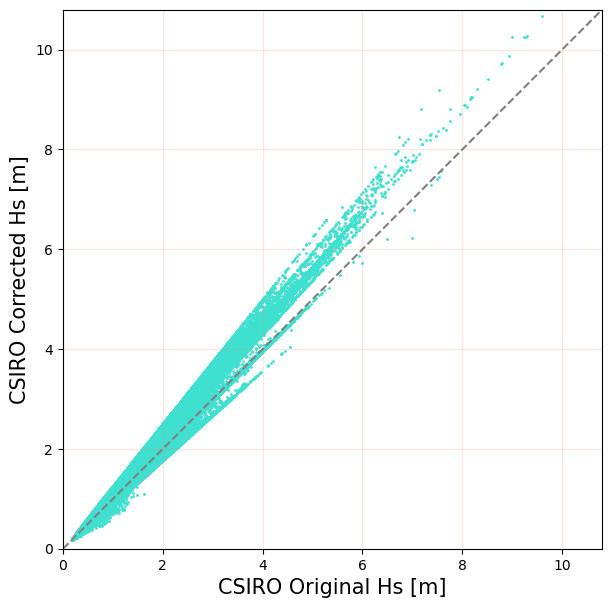

In [20]:
# Fix the subplot creation
fig, ax = plt.subplots(figsize=[20, 7])

ax.scatter(corrected_csiro.Hs, corrected_csiro.Hs_CORR, c='plum', s=3)
ax.scatter(corrected_csiro.Hs, full_spec.sum("part").spec.hs(), c='turquoise', s=1)
ax.plot([0, np.nanmax(corrected_csiro.Hs)+.2], [0, np.nanmax(corrected_csiro.Hs)+.2], '--', color='gray')
ax.set_aspect('equal')
ax.set_xlim([0, np.nanmax(corrected_csiro.Hs)+.2])
ax.set_ylim([0, np.nanmax(corrected_csiro.Hs)+.2])
ax.grid(color='coral', alpha=.2)
ax.set_xlabel('CSIRO Original Hs [m]', fontsize=15)
ax.set_ylabel('CSIRO Corrected Hs [m]', fontsize=15)

In [21]:
# Convert full_spec time to pandas DatetimeIndex
spec_times = pd.DatetimeIndex(full_spec.time.values)

# Find intersection with buoy times
common_times = buoy.index.intersection(spec_times)
print(f"Common timestamps: {len(common_times)}")

# Filter both to common times
buoy_common = buoy.loc[common_times]
csiro_common = full_spec.sel(time=common_times)

print(f"Buoy shape: {buoy_common.shape}")
print(f"Spec shape: {csiro_common.sizes}")

Common timestamps: 41282
Buoy shape: (41282, 7)
Spec shape: Frozen({'part': 4, 'time': 41282, 'freq': 29, 'dir': 24})


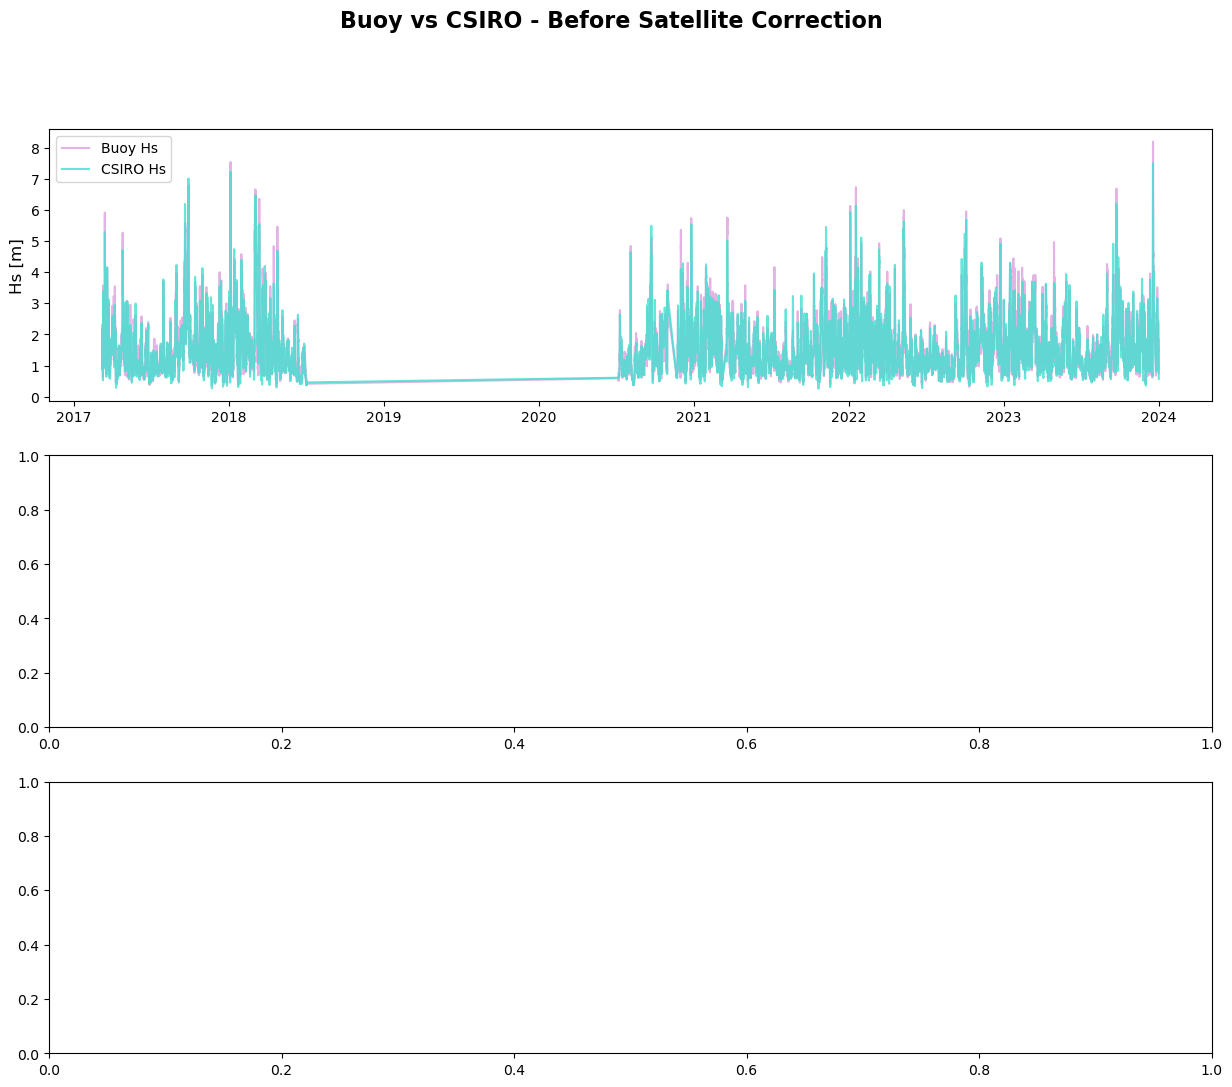

In [22]:
# Create time series plot
fig1, axes = plt.subplots(3, 1, figsize=(15, 12))
fig1.suptitle('Buoy vs CSIRO - Before Satellite Correction', fontsize=16, fontweight='bold')

# Hs time series
axes[0].plot(buoy_common.index, buoy_common['Hs_CAL'], color='plum', label='Buoy Hs', linewidth=1.5, alpha=0.8)
axes[0].plot(csiro_common.time, csiro_common.sum("part").spec.hs(), color='turquoise', label='CSIRO Hs', linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Hs [m]', fontsize=12)
axes[0].legend(fontsize=10)

# # Tp time series
# axes[1].plot(buoy_common.index, buoy_common['Tp_Buoy'], color='plum', label='Buoy Tp', linewidth=1.5, alpha=0.8)
# axes[1].plot(csiro_common.index, csiro_common['Tp'], color='turquoise', label='CSIRO Tp', linewidth=1.5, alpha=0.8)
# axes[1].set_ylabel('Tp [s]', fontsize=12)
# axes[1].legend(fontsize=10)

# # Dir time series
# axes[2].plot(buoy_common.index, buoy_common['Dir_Buoy'], color='plum', label='Buoy Dir', linewidth=1.5, alpha=0.8)
# axes[2].plot(csiro_common.index, csiro_common['Dm'], color='turquoise', label='CSIRO Dir', linewidth=1.5, alpha=0.8)
# axes[2].set_ylabel('Direction [°]', fontsize=12)
# axes[2].set_xlabel('Time', fontsize=12)
# axes[2].legend(fontsize=10)
# plt.tight_layout()
# plt.show()



/tmp/ipykernel_2476590/2861080738.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


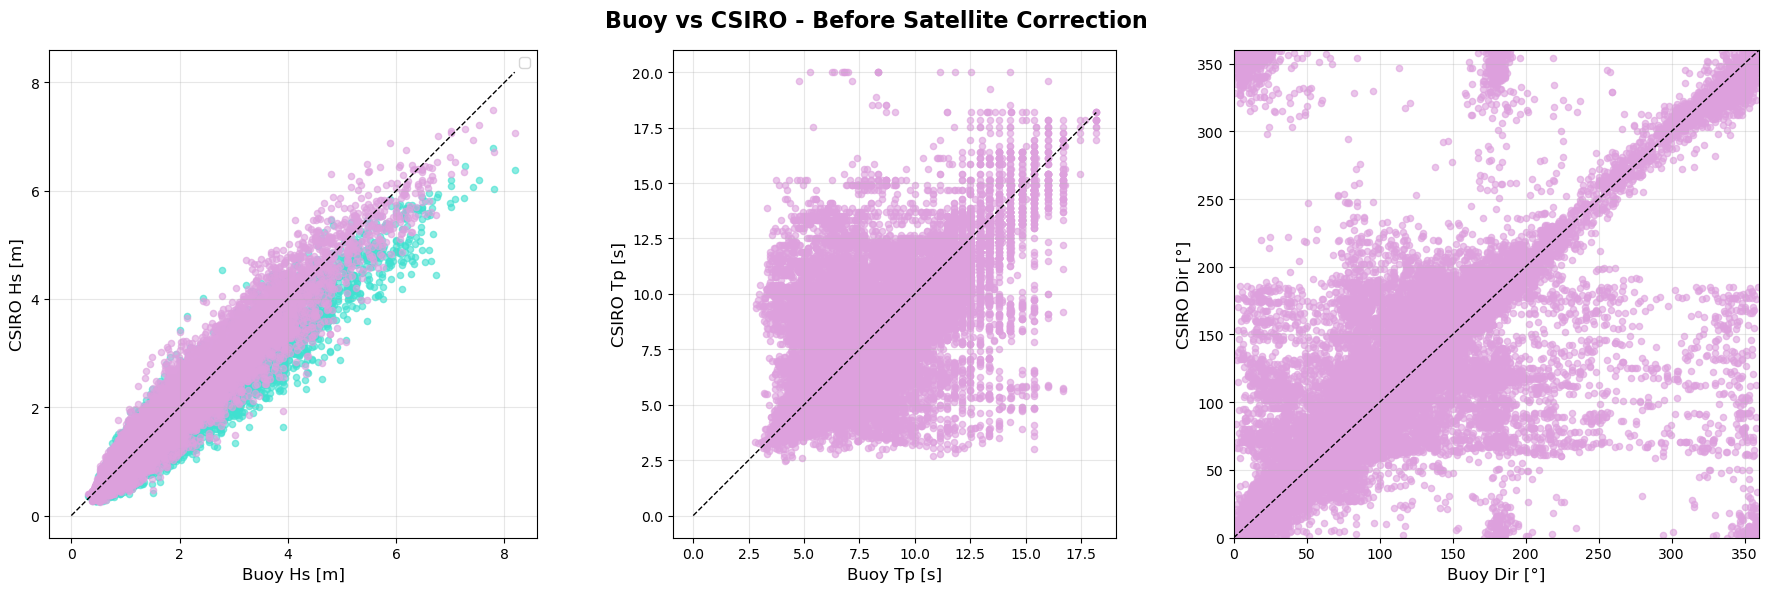

In [23]:
# Find common time range
common_start = max(buoy.index.min(), csiro.index.min())
common_end = min(buoy.index.max(), csiro.index.max())

# Filter data to common time range
buoy_common_ori = buoy[(buoy.index >= common_start) & (buoy.index <= common_end)]
csiro_common_ori = csiro[(csiro.index >= common_start) & (csiro.index <= common_end)]

# Merge data on time index for scatter plots (ADD THIS LINE)
merged_data_ori = buoy_common_ori.merge(csiro_common_ori, left_index=True, right_index=True, how='inner')

# Create scatter plots
fig2, axes = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Buoy vs CSIRO - Before Satellite Correction', fontsize=16, fontweight='bold')

# Merge data on time index for scatter plots


# Hs scatter plot - USE MERGED DATA INSTEAD
axes[0].scatter(merged_data_ori['Hs_CAL'], merged_data_ori['Hs'], alpha=0.6, s=20, color='turquoise')
axes[0].scatter(buoy_common['Hs_CAL'], csiro_common.sum("part").spec.hs(), alpha=0.6, s=20, color='plum')

axes[0].plot([0, merged_data_ori['Hs_CAL'].max()], [0, merged_data_ori['Hs_CAL'].max()], 'k--', linewidth=1)
axes[0].set_xlabel('Buoy Hs [m]', fontsize=12)
axes[0].set_ylabel('CSIRO Hs [m]', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Tp scatter plot
axes[1].scatter(merged_data['Tp_Buoy'], merged_data['Tp'], alpha=0.6, s=20, color='plum')
axes[1].plot([0, merged_data['Tp_Buoy'].max()], [0, merged_data['Tp_Buoy'].max()], 'k--', linewidth=1)
axes[1].set_xlabel('Buoy Tp [s]', fontsize=12)
axes[1].set_ylabel('CSIRO Tp [s]', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

# Dir scatter plot
axes[2].scatter(merged_data['Dir_Buoy'], merged_data['Dm'], alpha=0.6, s=20, color='plum')
axes[2].plot([0, 360], [0, 360], 'k--', linewidth=1)
axes[2].set_xlabel('Buoy Dir [°]', fontsize=12)
axes[2].set_ylabel('CSIRO Dir [°]', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 360)
axes[2].set_ylim(0, 360)

plt.tight_layout()
plt.show()

In [24]:
full_spec.sum("part").to_netcdf("outputs/44088_spec_WHACS_buoy_correted.nc")